# Reproduction - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case

## Load Dataset

In [17]:
from dataset import Dataset

dataset = Dataset(path="./data/state/ILINet.csv")
train_loader, vali_loader, test_loader = dataset.get_train_val_test_loader()

Train samples: 16052
Validation samples: 1784
Test samples: 4460


## ARIMA - Baseline Part

In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.tsa.arima.model import ARIMA

import statsmodels
import logging
logging.getLogger("statsmodels").setLevel(logging.ERROR)

In [40]:
# Load International ILI data
df_national = pd.read_csv("./data/national/ILINet.csv", header=1)
series = df_national["%UNWEIGHTED ILI"].values.astype(float)
 
print(f"Total weeks loaded : {len(series)}")
print(f"ILI range          : {series.min():.3f} ~ {series.max():.3f}")

# Sliding window — must match dataset.py parameters exactly
HISTORY = 10   # Input: Past 10 weeks
FUTURE  = 4    # Outout: 4 weeks
TEST_SIZE = 0.2

X, Y = [], []
for i in range(len(series) - HISTORY - FUTURE):
    X.append(series[i : i + HISTORY])
    Y.append(series[i + HISTORY : i + HISTORY + FUTURE])

X = np.array(X)  # (n_samples, 10)
Y = np.array(Y)  # (n_samples, 4)

split_idx = int(len(X) * (1 - TEST_SIZE))
X_test = X[split_idx:]
Y_test = Y[split_idx:]

print(f"\nTotal sliding windows : {len(X)}")
print(f"Test set size         : {len(X_test)} windows")
print(f"Each window           : {HISTORY} weeks in -> {FUTURE} weeks out")


Total weeks loaded : 417
ILI range          : 0.645 ~ 7.798

Total sliding windows : 403
Test set size         : 81 windows
Each window           : 10 weeks in -> 4 weeks out


In [41]:
def arima_predict_window(history_window, order=(3, 0, 3), steps=4):
    """
    Given a history window of length HISTORY, forecast the next `steps` values.
 
    Paper setting: ARIMA(3, 0, 3) with constant trend, order chosen by AIC/BIC.
 
    Args:
        history_window : np.array of shape (HISTORY,)
        order          : (p, d, q) tuple
        steps          : number of future steps to forecast
    Returns:
        np.array of shape (steps,)
    """
    try:
        model = ARIMA(history_window, order=order, trend="c")
        fit   = model.fit(method_kwargs={"maxiter": 200})
        return fit.forecast(steps=steps)
    except Exception:
        # Fallback: repeat the last observed value if fitting fails
        return np.full(steps, history_window[-1])
 
 
print("Running ARIMA(3,0,3) predictions...")
all_preds = []
 
for i, window in enumerate(X_test):
    pred = arima_predict_window(window, order=(3, 0, 3), steps=FUTURE)
    all_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(X_test)} windows done...")
 
all_preds  = np.array(all_preds)   # shape: (n_test, 4)
all_labels = Y_test                 # shape: (n_test, 4)
print("Done!")

Running ARIMA(3,0,3) predictions...
  10/81 windows done...
  20/81 windows done...
  30/81 windows done...
  40/81 windows done...
  50/81 windows done...
  60/81 windows done...
  70/81 windows done...
  80/81 windows done...
Done!


In [42]:
print("\n" + "="*50)
print("  ARIMA(3,0,3) Baseline Results")
print("="*50)
 
arima_metrics = {}
for step in range(FUTURE):
    p  = all_preds[:, step]
    l  = all_labels[:, step]
    rmse       = np.sqrt(np.mean((p - l) ** 2))
    mae        = np.mean(np.abs(p - l))
    pearson, _ = pearsonr(p, l)
    print(f"  Week+{step+1}: RMSE={rmse:.4f}  MAE={mae:.4f}  Pearson={pearson:.4f}")
    arima_metrics[f"week{step+1}"] = {"rmse": rmse, "mae": mae, "pearson": pearson}
 
# Overall metrics (flatten all steps)
p_all          = all_preds.flatten()
l_all          = all_labels.flatten()
overall_rmse    = np.sqrt(np.mean((p_all - l_all) ** 2))
overall_mae     = np.mean(np.abs(p_all - l_all))
overall_pearson, _ = pearsonr(p_all, l_all)
 
print("-"*50)
print(f"  Overall : RMSE={overall_rmse:.4f}  MAE={overall_mae:.4f}  Pearson={overall_pearson:.4f}")
print("="*50)
print("\n-> This is the baseline. The Transformer should beat these numbers!")
 
arima_metrics["overall"] = {
    "rmse": overall_rmse, "mae": overall_mae, "pearson": overall_pearson
}


  ARIMA(3,0,3) Baseline Results
  Week+1: RMSE=0.4107  MAE=0.2638  Pearson=0.9740
  Week+2: RMSE=0.9627  MAE=0.5991  Pearson=0.8566
  Week+3: RMSE=1.5317  MAE=0.9562  Pearson=0.6511
  Week+4: RMSE=1.9712  MAE=1.2809  Pearson=0.4531
--------------------------------------------------
  Overall : RMSE=1.3534  MAE=0.7750  Pearson=0.7254

-> This is the baseline. The Transformer should beat these numbers!


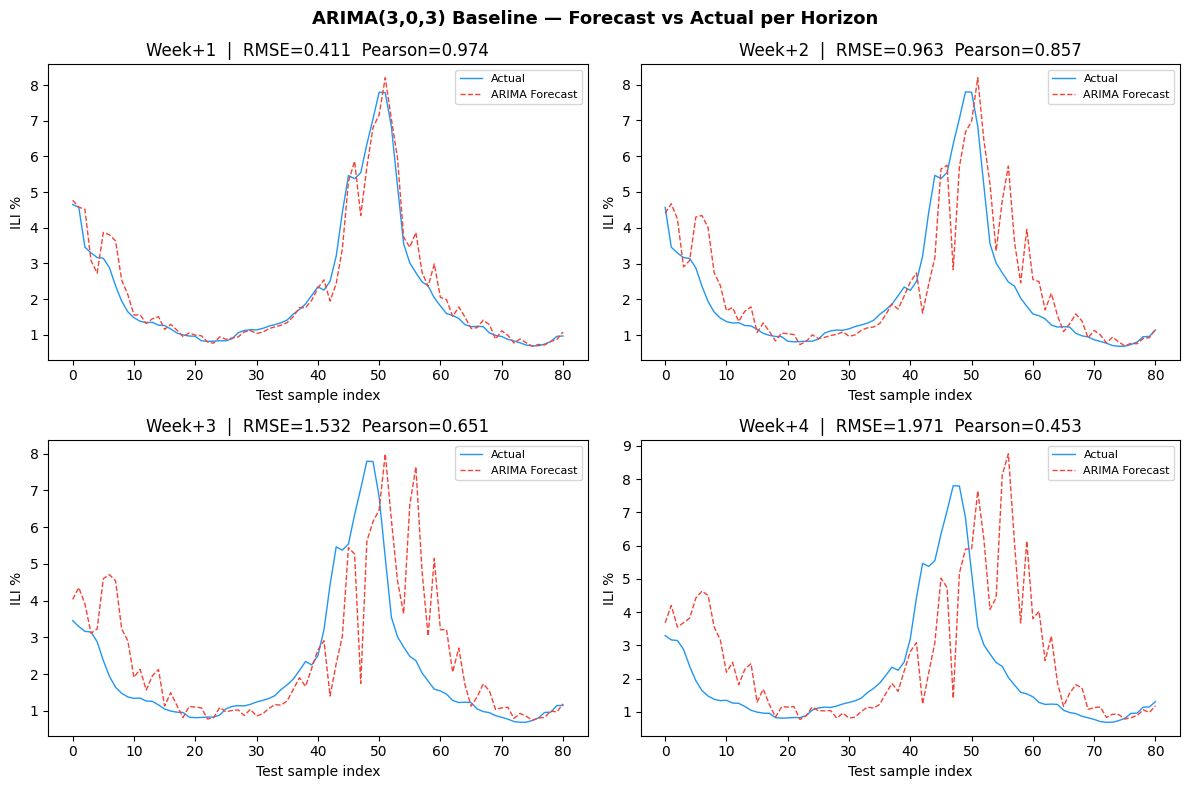

Plot saved: arima_baseline_results.png
Saved:
  arima_preds.npy   — ARIMA predictions, shape (n_test, 4)
  arima_labels.npy  — Ground truth labels, shape (n_test, 4)

Load these later to compare directly with Transformer results.


In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("ARIMA(3,0,3) Baseline — Forecast vs Actual per Horizon",
             fontsize=13, fontweight="bold")
 
for step in range(FUTURE):
    ax   = axes[step // 2][step % 2]
    rmse = arima_metrics[f"week{step+1}"]["rmse"]
    r    = arima_metrics[f"week{step+1}"]["pearson"]
 
    ax.plot(all_labels[:, step], color="#2196F3", linewidth=1.0, label="Actual")
    ax.plot(all_preds[:, step],  color="#F44336", linewidth=1.0,
            linestyle="--", label="ARIMA Forecast")
    ax.set_title(f"Week+{step+1}  |  RMSE={rmse:.3f}  Pearson={r:.3f}")
    ax.set_ylabel("ILI %")
    ax.set_xlabel("Test sample index")
    ax.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig("arima_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: arima_baseline_results.png")
 

 
np.save("arima_preds.npy",  all_preds)
np.save("arima_labels.npy", all_labels)
print("Saved:")
print("  arima_preds.npy   — ARIMA predictions, shape (n_test, 4)")
print("  arima_labels.npy  — Ground truth labels, shape (n_test, 4)")
print("\nLoad these later to compare directly with Transformer results.")

## Deep Transformer Model

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import matplotlib.pyplot as plt


class DeepTransformer:
    pass

In [32]:
class PipeLine:
    def __init__(self, model, train_loader, val_loader, warmup_steps=5000, d_model=64):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.d_model = d_model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.warmup_steps = warmup_steps
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            betas=(0.9, 0.98),
            eps=1e-9
        )
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer,
            lr_lambda=self.lr_lambda
        )
        self.loss_func = nn.MSELoss()

    def lr_lambda(self, step):
        step = max(step, 1)
        lr = (self.d_model ** (-0.5)) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))
        return lr

    def train_model(self, epochs):
        train_losses = []
        val_losses = []
    
        best_val_loss = float("inf")
        best_model = None

        for epoch in range(1, epochs+1):
            train_loss = self.train_one_epoch()
            train_losses.append(train_loss)
    
            val_loss = self.evaluate(self.val_loader)
            val_losses.append(val_loss)
    
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(self.model)
    
            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        return best_model, train_losses, val_losses
    
    def train_one_epoch(self):
        """
        Run one full pass over the training dataloader and return the average loss.
        """
        self.model.train()
        total_loss, total_count = 0.0, 0
        for xb, yb in self.train_loader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            self.optimizer.zero_grad()
    
            pred = None
            pred = self.model(xb)
            loss = self.loss_func(pred, yb)
            loss.backward()
    
            self.optimizer.step()
            self.scheduler.step()
            total_loss  += loss.item() * xb.size(0)
            total_count += xb.size(0)
        return total_loss / total_count

    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model on valid dataloader without updating weights.
        Returns the average loss.
        """
        self.model.eval()
        total_loss, total_count = 0.0, 0
    
        for xb, yb in dataloader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            pred = self.model(xb)
            loss = self.loss_func(pred, yb)
    
            total_loss  += loss.item() * xb.size(0)
            total_count += xb.size(0)
        return total_loss / total_count

ARIMA - Baseline Part

In [33]:
import pandas as pd
df = pd.read_csv("./data/national/ILINet.csv", header=1)
print(df.columns.tolist())
print(df.head(3))
print(len(df))

['REGION TYPE', 'REGION', 'YEAR', 'WEEK', '% WEIGHTED ILI', '%UNWEIGHTED ILI', 'AGE 0-4', 'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS']
  REGION TYPE REGION  YEAR  WEEK  % WEIGHTED ILI  %UNWEIGHTED ILI  AGE 0-4  \
0    National      X  2010    40         1.10939          1.13505     2627   
1    National      X  2010    41         1.24341          1.25256     2953   
2    National      X  2010    42         1.25726          1.24570     3044   

   AGE 25-49 AGE 25-64  AGE 5-24  AGE 50-64  AGE 65  ILITOTAL  \
0       1677         X      3142        627     400      8473   
1       1779         X      3522        649     444      9347   
2       1898         X      3641        690     411      9684   

   NUM. OF PROVIDERS  TOTAL PATIENTS  
0               1838          746485  
1               1875          746230  
2               1907          777397  
417


# Improvement - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case